# 1D berekening indringingslengte

In het technisch rapport Waterspanningen bij dijken is in b4.3 de aanpassing van de waterspanningen $u$ in een kleilaag aan een wijziging van de randvoorwaarde beschreven.

Deze notebook verkent de aanpassing van de waterspanning $u$ in een kleilaag aan een wijziging van de waterspanning in een onderliggende watervoerende laag. Het aanpassingsproces wordt beschreven door de vergelijking voor eendimensionale consolidatie:

$\frac{\partial u}{\partial t} = c_{v} \frac{\partial ^{2} u}{\partial z^{2}}$

met 
* $u$ als de mate van aanpassing in de deklaag, gegeven de belasting ($u = [0..1]$) [-]
* $z$ de indringing ten opzichte van de onderkant van de deklaag [m]$
* $c_{u}$ de consolidatiecoëfficiënt in de ontlasttrap [m2/s]


De relatie tussen de consolidatiecoëfficiënt $c_{v}$ en de doorlatendheid en samendrukbaarheid is in 

$c_{v} = \frac{k}{\gamma_{w} (m_{v} + n \beta)}$

De consolidatiecoëfficiënt $c_{v}$ heeft de eenheid m²/s. de overige parameters zijn:
* $k$ is de doorlatendheid van de grond in m/s
* $\gamma_{w}$ het volumieke gewicht van de grond in N/m³
* $m_{v}$ is de samendrukbaarheid van de grond in m²/N
* $n$ de pororiteit van de grond
* $\beta$ de samendrukbaarheid van het water in m²/N. 

Globaal geldt voor klei $m_{v}$ = 10<sup>-7</sup> à 10<sup>-6</sup> m²/N en voor water $\beta$ = 0.5*10<sup>-9</sup> m²/N.

De consolidatiecoëfficiënt ligt gebruikelijk tussen $c_{v}$ = 10<sup>-4</sup> à 10<sup>-8</sup> m²/s.

## Uitwerking
In de mathematische fysica noemt men een vergelijking van dit type een diffusievergelijking. In deze uitwerking maken we gebruik van het voorbeeld op deze [website](https://www.ctcms.nist.gov/fipy/). 


In [ ]:
from fipy import (
    Grid1D,
    CellVariable,
    Variable,
    TransientTerm,
    ExplicitDiffusionTerm,
    DiffusionTerm,
)
import numpy as np
import matplotlib.pyplot as plt
from wsbd.waterstandsverloop import (
    ComponentWaterstandsVerloop,
    GetijdeVerloop,
    WaterstandsVerloop,
)

## belastingsfunctie

In dit voorbeeld gebruiken we de waterstandsgenerator.

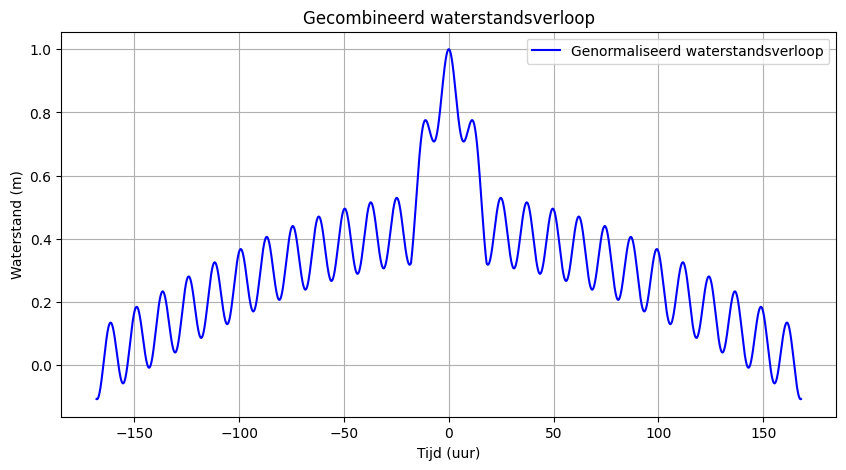

In [ ]:
topwaterstand = 3.77
gemiddelde_waterstand = 1.0
amplitude_getijde = 0.3
amplitude_afvoergolf = 1.2
amplitude_stormopzet = (
    topwaterstand - gemiddelde_waterstand - amplitude_getijde - amplitude_afvoergolf
)

getijde = GetijdeVerloop(
    periode=(12 * 3600 + 25 * 60),
    amplitude=amplitude_getijde,
    faseverschuiving=-0 * 3600,
    dt=1.0,
)
afvoergolf = ComponentWaterstandsVerloop(
    component="afvoergolf",
    stormduur=14 * 24 * 3600,
    amplitude=amplitude_afvoergolf,
    dt=1.0,
)
stormopzet = ComponentWaterstandsVerloop(
    component="stormopzet", stormduur=36 * 3600, amplitude=amplitude_stormopzet, dt=1.0
)

waterstandsverloop = WaterstandsVerloop(
    afvoergolf=afvoergolf, stormopzet=stormopzet, getijde=getijde, dt=1.0
)


waterstandsverloop.plot(normalised=True)


In [ ]:
# assign variables for fipy
tijd, _, ws_u = waterstandsverloop.generate_waterstandsverloop()
# tijd must start at 0, so we shift it to start at 0
tijd = tijd - tijd[0]
tijd_max = tijd.max()  # maximum time in seconds
print(len(tijd), "time steps")  # number of time steps
print(tijd_max / (24 * 3600), "dagen")  # print time length in days (14)

# check if tijd is strictly increasing
if not np.all(np.diff(tijd) > 0):
    raise ValueError("tijd must be strictly increasing")
else:
    print("tijd is strictly increasing")

# negative ws_u values are not helpful for boundary conditions, so we set them to 0
ws_u[ws_u < 0] = 0


# define function to calculate boundary condition for given time based on waterstandsverloop
def boundary(t, tijd, ws_u):
    return np.interp(t, tijd, ws_u)


print("boundary condition at t=0:", boundary(0, tijd, ws_u))
print("boundary condition at t=7 days:", boundary(7 * 24 * 3600, tijd, ws_u))
print("boundary condition at t=14 days:", boundary(14 * 24 * 3600, tijd, ws_u))

1209601 time steps
14.0 dagen
tijd is strictly increasing
boundary condition at t=0: 0.0
boundary condition at t=7 days: 1.0
boundary condition at t=14 days: 0.0


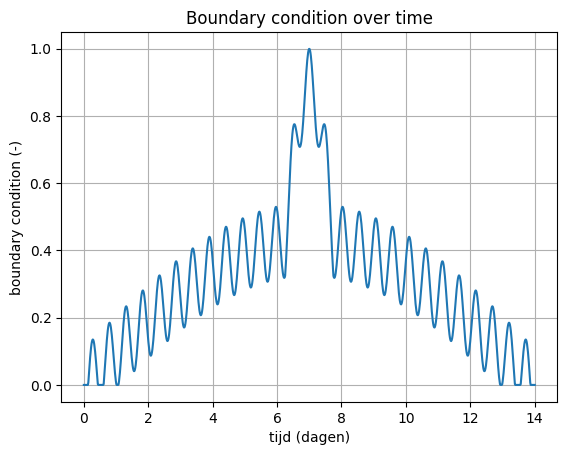

In [ ]:
# plot boundary condition over time
t_plot = np.linspace(0, tijd_max, 1000)
boundary_plot = boundary(t_plot, tijd, ws_u)
plt.figure()
plt.plot(t_plot / (24 * 3600), boundary_plot)
plt.xlabel("tijd (dagen)")
plt.ylabel("boundary condition (-)")
plt.title("Boundary condition over time")
plt.grid()
plt.show()

In [ ]:
# set up problem
# x=0 means bottom of cover layer
nx = 50  # number of cells in x direction
d = 4.0  # thickness of the cover layer
dx = d / nx  # mesh size
cv = 2 * 10 ** (-6)  # consolidation coëfficiënt of the subsoil (m2/s)
# create grid
mesh = Grid1D(dx=dx, nx=nx, Lx=d)
# create model
u = CellVariable(mesh=mesh, name="pore pressure variable", value=0.0, hasOld=True)
# set cv as celvariable use np.concatenate to explore the effect of a layered soil with different cv values in the top and bottom half of the cover layer
# values from bottom to top of the cover layer, so the first 15 cells have cv=2e-6 and the next 35 cells have cv=1e-6
cv_cell = CellVariable(
    mesh=mesh,
    name="consolidation coëfficiënt m/s²",
    value=np.concatenate((np.full([15], 1.0 * cv), 
                          np.full([35], 1.0 * cv)), axis=None),
)

# define time as variable
t = Variable(value=0.0)
# boundary conditions
bc_left = Variable(value=boundary(0.0, tijd, ws_u))
u.constrain(bc_left, mesh.facesLeft)
u.constrain(0.0, mesh.facesRight)
# set up solvers
# eqX = TransientTerm() == ExplicitDiffusionTerm(coeff=cv) #explicit
# eqI = TransientTerm() == DiffusionTerm(coeff=cv) #implicit
eqX = TransientTerm() == ExplicitDiffusionTerm(cv_cell)  # explicit
eqI = TransientTerm() == DiffusionTerm(cv_cell)  # implicit
eqCN = eqX + eqI  # Crank-Nicholson transient diffusion
# discretisation in Time
dt = 0.9 * dx**2 / (2 * cv)  # time step 90% of explicit 1D diffusion problem
time_length = tijd_max  # time length in [s]
steps = int(time_length / dt)
u_out = np.zeros((steps, nx))  # array to collect results
t_out = np.zeros((steps))  # list to collect time
# measure time of calculation
import time

t1 = time.time()
for step in range(steps):
    t.setValue(t() + dt)
    u.updateOld()
    t_out[step] = t.numericValue
    bc_left.setValue(boundary(t(), tijd, ws_u))
    eqI.solve(var=u, dt=dt)
    u_out[step] = u.globalValue
print("Execution time: %.3f" % (time.time() - t1))

Execution time: 2.566


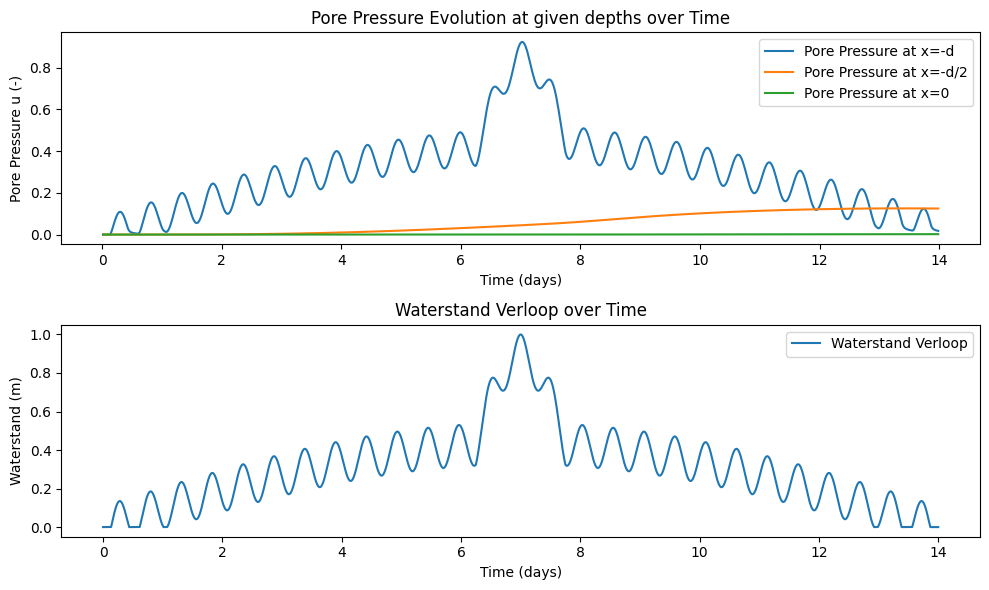

In [ ]:
# define plotting function
def plot_results(t_out, u_out, tijd, ws_u):
    # plot results
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t_out / (24 * 3600), u_out[:, 0], label="Pore Pressure at x=-d")
    plt.plot(t_out / (24 * 3600), u_out[:, nx // 2], label="Pore Pressure at x=-d/2")
    plt.plot(t_out / (24 * 3600), u_out[:, -1], label="Pore Pressure at x=0")
    plt.xlabel("Time (days)")
    plt.ylabel("Pore Pressure u (-)")
    plt.title("Pore Pressure Evolution at given depths over Time")
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(tijd / (24 * 3600), ws_u, label="Waterstand Verloop")
    plt.xlabel("Time (days)")
    plt.ylabel("Waterstand (m)")
    plt.title("Waterstand Verloop over Time")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_results(t_out, u_out, tijd, ws_u)

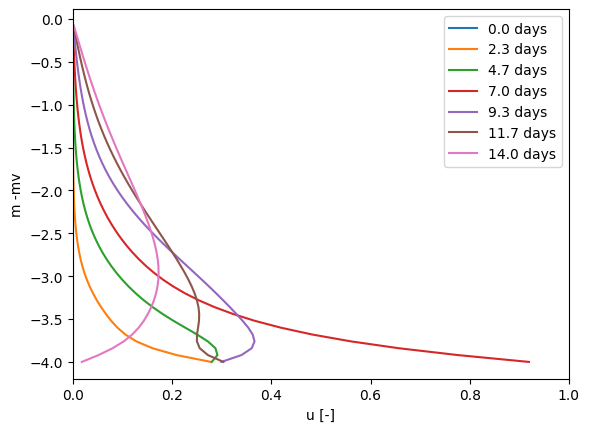

In [ ]:
# maatvoering voor dagen
t_ticks_days = t_out / (24 * 3600)
# maatvoering dx
y_ticks = np.arange(-d, 0.0, dx)


def plot_profiel(u_out, t_out, y_ticks, n_lijnen=7):
    t_ticks_days = t_out / (24 * 3600)
    indices = np.linspace(0, len(u_out) - 1, n_lijnen, dtype=int)
    for i in indices:
        plt.plot(u_out[i], y_ticks, label=f"{round(t_ticks_days[i], 1)} days")

    plt.xlim(0.0, 1.0)
    plt.xlabel("u [-]")
    plt.ylabel("m -mv")
    plt.legend()
    plt.show()


plot_profiel(u_out, t_out, y_ticks, n_lijnen=7)